TABLEAU A CONSTRUIRE

* lignes : INDEX 1 = dataset/model ; INDEX 2 = $\kappa_f$ ; INDEX 3 = 'hyperparameter value': n=... puis imbalance=... puis $\delta$=... 

* colonnes = normalized Areas Between Curves (ADBC, between bounds curve and test metric curve, normalized by number of common $\theta$ points on x-axis): R0/1, R0/1, FPP, FPP, ..., moyennes calculées sur 10 splits de CV



In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
from IPython.display import clear_output
import pickle
import ast
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
datasets_paths = [
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/CIFAR2/sgp_set_cnn',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/CIFAR2/sgp_set_resnet',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/CIFAR2/sgp_set_cnn_MCD',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/WSI/sgp_set_cnn',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/WSI/sgp_set_cnn_MCD'
]

In [3]:
num_seeds = 50

In [4]:
dicos = []
datasets = ['CIFAR2', 'WSI']
models = ["cnn", "resnet"]

for path in datasets_paths:

    print('Considering ', path)
    mod = models[int(np.where([(m in path) for m in models])[0][0])]
    ds = datasets[int(np.where([(d in path) for d in datasets])[0][0])]
    if 'MCD' in path:
        kappa = 'MCD'
    else:
        kappa = 'SR'

    original_ds = pickle.load(open(path, 'rb'))

    print('Sample size proportions...')
    for prop in np.linspace(1/4,1,num=6):
        print('prop = ', prop)
        for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
            print("metric = ", metric)
            values = []
            for seed in tqdm(range(num_seeds)):
                df = original_ds.sample(frac=prop, random_state=seed)
                values.append(ABC(df, metric=metric))
            dicos.append({'dataset': ds,
                            'model': mod,
                            'kappa': kappa,
                            'metric': metric,
                            'param.': 'N',
                            'value': prop,
                            'ADBC': np.mean(values),
                            'CI': [np.mean(values)-1.96*np.std(values),
                                np.mean(values)+1.96*np.std(values)]})

    print('Imbalance rates...')
    for imbalance in np.linspace(1/6,5/6,num=5):
        print('imbalance = ', imbalance)
        for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
            print('metric = ', metric)
            values = []
            for seed in tqdm(range(num_seeds)):
                df = generate_imbalanced_datasets(original_ds, [imbalance], seed=seed)[0]
                values.append(ABC(df, metric=metric))
            dicos.append({'dataset': ds,
                        'model': mod,
                        'kappa': kappa,
                        'metric': metric,
                        'param.': 'imbalance',
                        'value': imbalance,
                        'ADBC': np.mean(values),
                        'CI': [np.mean(values)-1.96*np.std(values),
                                np.mean(values)+1.96*np.std(values)]})
            
    print(r'$\delta$ values...')
    for delta in np.linspace(0.001,0.1,num=6):
        print('delta = ', delta)
        for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
            print('metric = ', metric)
            values = []
            for seed in tqdm(range(num_seeds)):
                df = original_ds.sample(frac=1, random_state=seed)
                values.append(ABC(df, metric=metric, delta=delta))
            dicos.append({'dataset': ds,
                            'model': mod,
                            'kappa': kappa,
                            'metric': metric,
                            'param.': 'delta',
                            'value': delta,
                            'ADBC': np.mean(values),
                            'CI': [np.mean(values)-1.96*np.std(values),
                                np.mean(values)+1.96*np.std(values)]})
            
    clear_output(wait=True)

Considering  C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/WSI/sgp_set_cnn_MCD
Sample size proportions...
prop =  0.25
metric =  standard


100%|██████████| 50/50 [00:11<00:00,  4.24it/s]


metric =  FP


100%|██████████| 50/50 [00:10<00:00,  4.77it/s]


metric =  FN


...

100%|██████████| 50/50 [00:10<00:00,  4.84it/s]


metric =  FPR


100%|██████████| 50/50 [00:58<00:00,  1.17s/it]


metric =  FNR


100%|██████████| 50/50 [00:10<00:00,  4.81it/s]


In [5]:
res = pd.DataFrame(dicos)
display(res)

,dataset,model,kappa,metric,param.,value,ADBC,CI
0,CIFAR2,cnn,SR,standard,N,0.25,0.020337,"[0.00951664253183195, 0.031158135298820354]"
1,CIFAR2,cnn,SR,FP,N,0.25,0.019642,"[0.008524597392563055, 0.030759465462771335]"
2,CIFAR2,cnn,SR,FN,N,0.25,0.008679,"[0.002368895319190276, 0.014988870693162818]"
3,CIFAR2,cnn,SR,FPR,N,0.25,0.037329,"[0.009799581725910632, 0.06485843417524514]"
4,CIFAR2,cnn,SR,FNR,N,0.25,0.374181,"[0.2855155696607707, 0.46284688076480257]"
...,...,...,...,...,...,...,...,...
420,WSI,cnn,MCD,standard,delta,0.10,0.007936,"[-0.0008664299730182044, 0.016738245048819052]"
421,WSI,cnn,MCD,FP,delta,0.10,0.007621,"[-0.0014492457577292544, 0.016691495546473624]"
422,WSI,cnn,MCD,FN,delta,0.10,0.003410,"[-0.0009696689724139791, 0.007788767219479405]"
423,WSI,cnn,MCD,FPR,delta,0.10,0.015309,"[-0.0009321637257548154, 0.03154929917160109]"


In [6]:
pickle.dump(res, open('hyperparams_impact_res', 'wb'))

In [7]:
impact_df = pickle.load(open('hyperparams_impact_res','rb'))

In [9]:
df

,dataset,model,kappa,metric,param.,value,ADBC,CI
0,CIFAR2,cnn,SR,standard,N,0.25,0.020337,"[0.00951664253183195, 0.031158135298820354]"
1,CIFAR2,cnn,SR,FP,N,0.25,0.019642,"[0.008524597392563055, 0.030759465462771335]"
2,CIFAR2,cnn,SR,FN,N,0.25,0.008679,"[0.002368895319190276, 0.014988870693162818]"
3,CIFAR2,cnn,SR,FPR,N,0.25,0.037329,"[0.009799581725910632, 0.06485843417524514]"
4,CIFAR2,cnn,SR,FNR,N,0.25,0.374181,"[0.2855155696607707, 0.46284688076480257]"
...,...,...,...,...,...,...,...,...
420,WSI,cnn,MCD,standard,delta,0.10,0.007936,"[-0.0008664299730182044, 0.016738245048819052]"
421,WSI,cnn,MCD,FP,delta,0.10,0.007621,"[-0.0014492457577292544, 0.016691495546473624]"
422,WSI,cnn,MCD,FN,delta,0.10,0.003410,"[-0.0009696689724139791, 0.007788767219479405]"
423,WSI,cnn,MCD,FPR,delta,0.10,0.015309,"[-0.0009321637257548154, 0.03154929917160109]"


In [14]:
# Define custom order
order = ["standard", 
         "FP", 
         "FN",
         "FPR",
         "FNR"]

df["metric"] = pd.Categorical(df["metric"], categories=order, ordered=True)

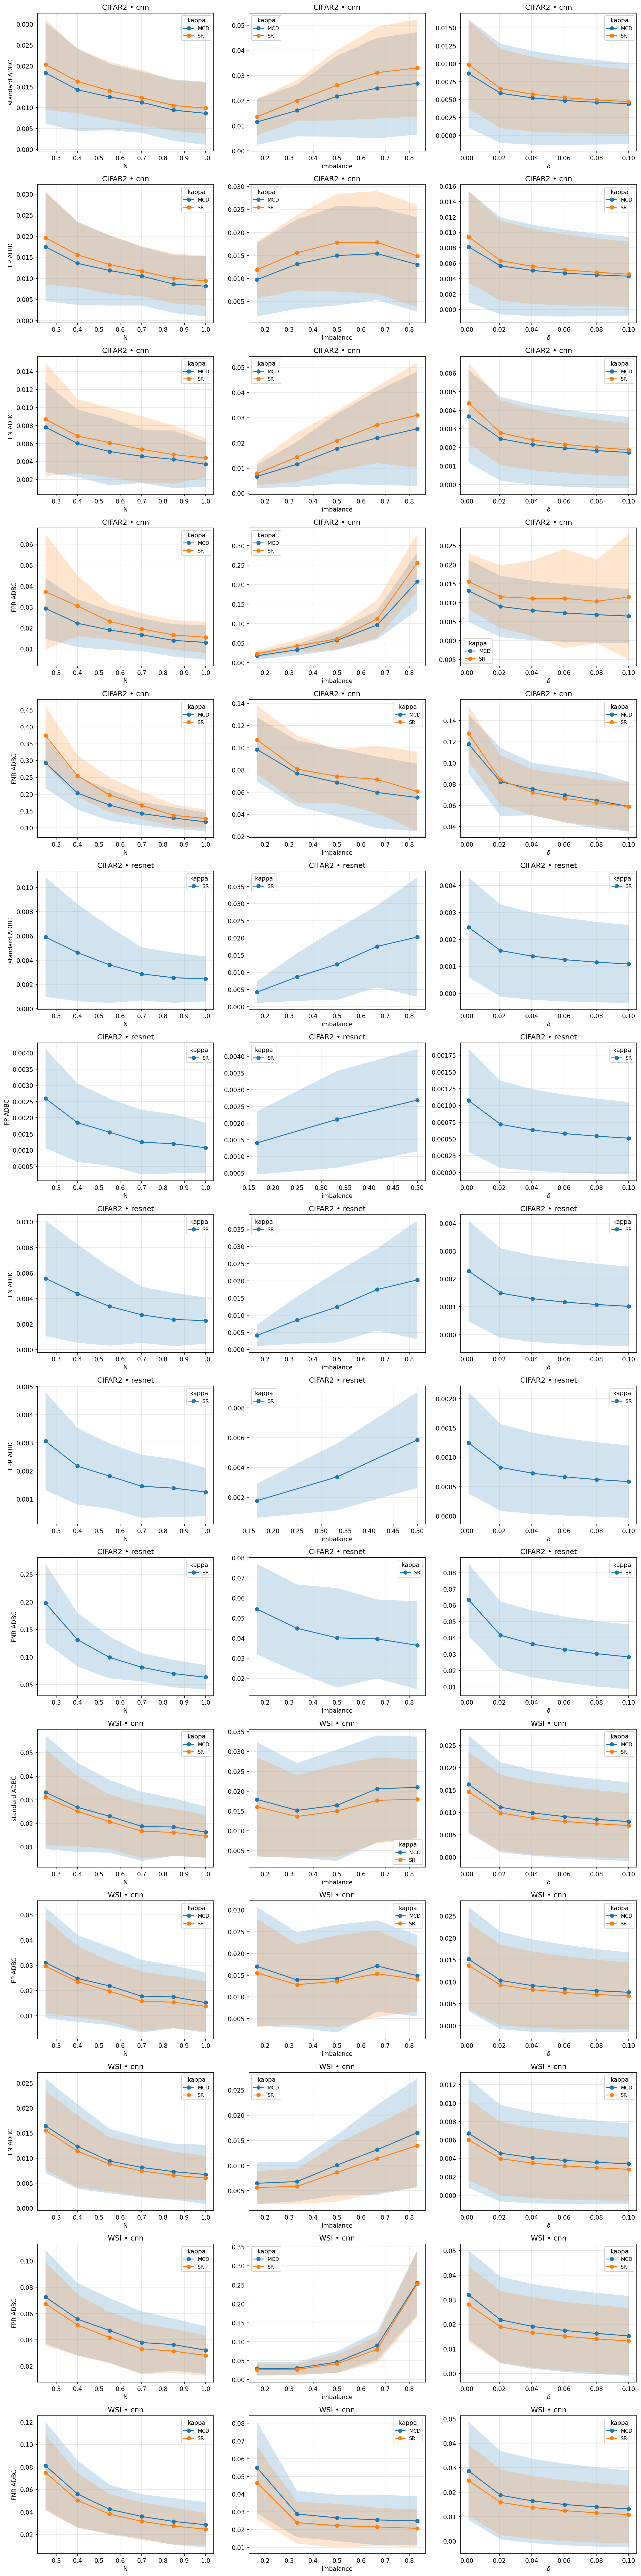

In [17]:
# df = your DataFrame
# If CI is a string like "[low, high]", convert it to a list
if isinstance(df["CI"].iloc[0], str):
    df["CI"] = df["CI"].apply(ast.literal_eval)

# Split CI into bounds
df["CI_low"] = df["CI"].apply(lambda x: x[0])
df["CI_high"] = df["CI"].apply(lambda x: x[1])

# --- layout: rows = (dataset, model, metric), cols = param. ---
row_groups = list(df.groupby(["dataset", "model", "metric"]))
n_rows = len(row_groups)

# how many params per row (max → columns)
def n_params(g):
    return g["param."].nunique()
n_cols = max(n_params(g) for _, g in row_groups)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), squeeze=False)

for row_idx, ((dataset, model, metric), g_row) in enumerate(row_groups):
    # preserve first-seen order of params within this row
    params_order = list(dict.fromkeys(g_row["param."].tolist()))
    # fallback: if for some reason empty, skip
    if len(params_order) == 0:
        continue

    for col_idx, param in enumerate(params_order):
        ax = axes[row_idx, col_idx]
        g_param = g_row[g_row["param."] == param]

        # one line per kappa
        for kappa, g_k in g_param.groupby("kappa"):
            # sort by x to get clean lines
            g_k = g_k.sort_values("value")
            ax.plot(g_k["value"], g_k["ADBC"], marker="o", label=f"{kappa}")
            ax.fill_between(g_k["value"], g_k["CI_low"], g_k["CI_high"], alpha=0.2)

        # titles + labels
        ax.set_title(f"{dataset} • {model}")
        if param=='delta':
            ax.set_xlabel(r'$\delta$')    
        else:
            ax.set_xlabel(param)  # x-label is the parameter name
        if col_idx == 0:
            ax.set_ylabel(f"{metric} ADBC")  # only leftmost column to reduce clutter
        ax.grid(True, alpha=0.3)
        ax.legend(title="kappa", fontsize="small")

    # remove unused axes for this row (if fewer params than n_cols)
    for col_idx in range(len(params_order), n_cols):
        fig.delaxes(axes[row_idx, col_idx])

plt.tight_layout()
plt.show()
